In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_dir  = "C:\Salem\AI\CK"

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [4]:
train_datagen=ImageDataGenerator(
    rescale=1.0/225,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [5]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 2710 images belonging to 14 classes.


In [6]:
model_food= Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(14, activation= 'softmax')
])

c:\Salem\AI\Anh AI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_food.compile(optimizer='adam',
                   loss='categorical_crossentropy',
               metrics=['accuracy'])
model_food.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,781,582 (14.43 MB)

 Trainable params: 3,781,582 (14.43 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
epochs=200
history=model_food.fit(train_generator,epochs=epochs)

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.3819 - loss: 1.7751
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.3941 - loss: 1.7541
Epoch 3/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.3978 - loss: 1.7078
Epoch 4/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.4476 - loss: 1.6199
Epoch 5/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.4421 - loss: 1.6161
Epoch 6/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.4487 - loss: 1.5865
Epoch 7/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - accuracy: 0.4819 - loss: 1.5134
Epoch 8/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.4908 - loss: 1.4804
Epoch 9/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 31s 362ms/step - accuracy: 0.4856 - loss: 1.5025
Epoch 10/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 29s 340ms/step - accuracy: 0.4934 - loss: 1.5034
Epoch 11/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 274ms/step - accuracy: 0.5000 - loss: 1.4293
Epoch 12/200
85/85 ━━━━━━━━━━━

In [12]:
model_food.save("model_food.h5")

In [13]:
from keras.models import load_model
model1 = load_model("model_food.h5")

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

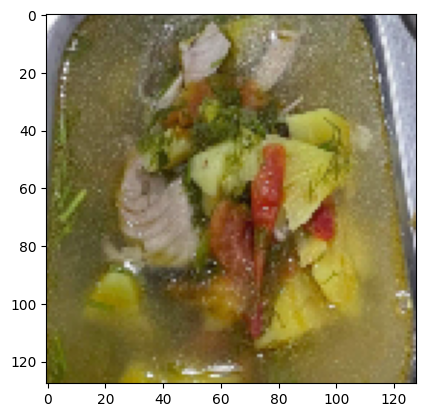

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Món ăn tiên đoán: canh_chua_co_ca
Độ tự tin: 55.28%


In [15]:
img = cv2.imread("Screenshot 2026-06-10 173457.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món ăn tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

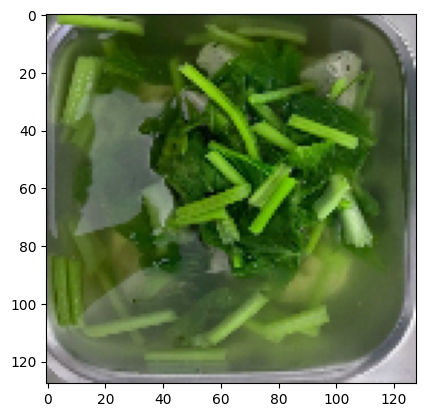

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Món ăn tiên đoán: canh_rau_cai
Độ tự tin: 91.25%


In [16]:
img = cv2.imread("Screenshot 2026-06-11 103716.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món ăn tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

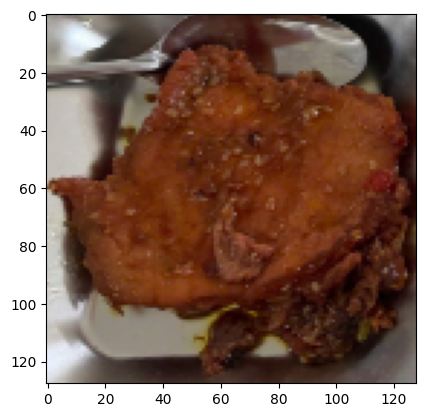

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Món ăn tiên đoán: suon
Độ tự tin: 91.68%


In [17]:
img = cv2.imread("Screenshot 2026-06-10 172950.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món ăn tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

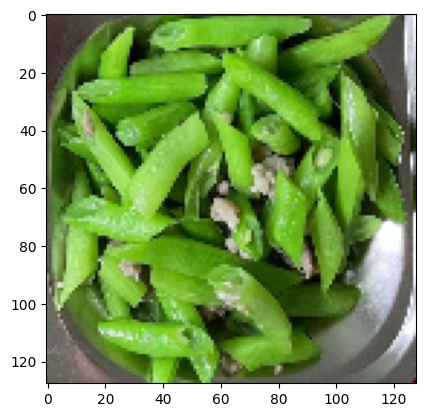

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Món ăn tiên đoán: dau_dua_xao
Độ tự tin: 57.92%


In [18]:
img = cv2.imread("Screenshot 2026-06-10 173846.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món ăn tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

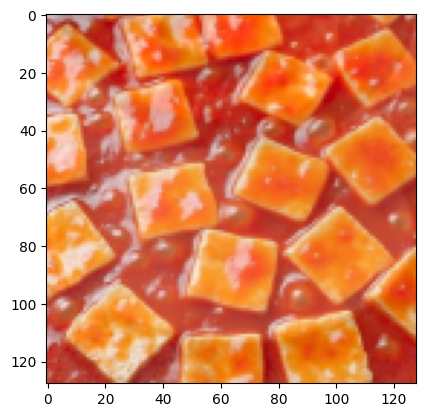

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Món ăn tiên đoán: dau-sot-ca
Độ tự tin: 82.63%


In [19]:
img = cv2.imread("Screenshot 2026-06-10 192705.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món ăn tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")